<a href="https://colab.research.google.com/github/johnlaraji1608-collab/ridge_regression_dataset/blob/main/ridge_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [3]:
x,y=make_regression(n_samples=100 , n_features=1,n_targets=1,n_informative=1,noise=20,random_state=13)

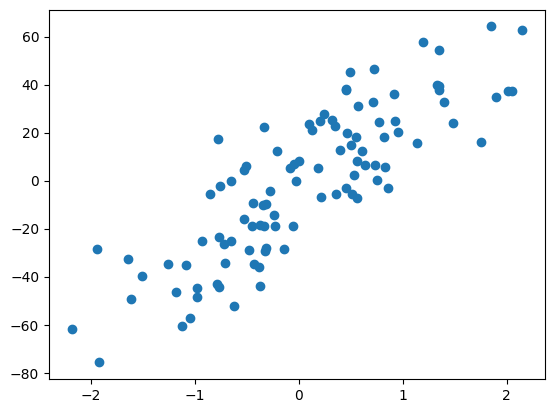

In [4]:
plt.scatter(x,y)

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
lr=LinearRegression()
lr.fit(x,y)

LinearRegression()

In [7]:
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [8]:
from sklearn.linear_model import Ridge

In [9]:
r=Ridge(alpha=10)
r.fit(x,y)
print(r.coef_)
print(r.intercept_)

[24.9546267]
-2.126913003523573


In [10]:
r1=Ridge(alpha=50)
r1.fit(x,y)
print(r1.coef_)
print(r1.intercept_)

[17.66035643]
-1.7008737066555062


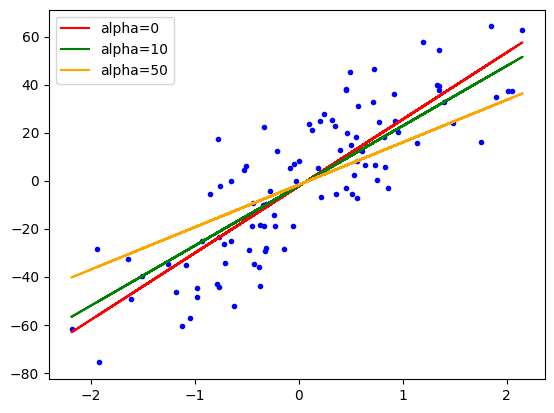

In [11]:
plt.plot(x,y,'b.')
plt.plot(x,lr.predict(x),color='red',label='alpha=0')
plt.plot(x,r.predict(x),color='green',label='alpha=10')
plt.plot(x,r1.predict(x),color='orange',label='alpha=50')
plt.legend()

In [12]:
def linear_regression(X,y,alpha=1):
    x_mean = X.mean()
    y_mean = y.mean()

    num = 0
    den = 0

    for i in range(X.shape[0]):
        num = num + (y[i] - y_mean) * (X[i] - x_mean)
        den = den + (X[i] - x_mean) * (X[i] - x_mean)

    m = num/(den + alpha)
    b = y_mean - m*x_mean

    return m,b


In [13]:
class MeraRidge:

    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self,X_train,y_train):

        num = 0
        den = 0

        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean())

        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m*X_train.mean())
        print(self.m,self.b)

    def predict(X_test):
        return self.m*x + self.b


In [14]:
reg = MeraRidge(alpha=100)
reg.fit(x,y)

[12.93442104] [-1.42484415]


In [15]:
from sklearn.datasets import load_diabetes

data=load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [16]:
X=data.data
y=data.target
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)
from sklearn.linear_model import LinearRegression
L=LinearRegression()
L.fit(X_train,y_train)

LinearRegression()

In [17]:
print(L.coef_)
print(L.intercept_)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [18]:
Y_predict=L.predict(X_test)

In [20]:
from sklearn.metrics import r2_score,mean_squared_error

print("R2 score",r2_score(y_test,Y_predict))
print("RMSE",np.sqrt(mean_squared_error(y_test,Y_predict)))

R2 score 0.5188113124539246
RMSE 48.727137609532534
